In [ ]:
pip install pandas numpy matplotlib seaborn openpyxl

In [ ]:
# ============================================
# SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization style
sns.set_theme(style="whitegrid", palette="deep")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the dataset
file_path = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (4000, 28)


In [ ]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 4000
Number of columns: 28


In [ ]:
print("Column Names:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Column Names:

1 : Farm_ID
2 : State
3 : District
4 : Crop
5 : Season
6 : Farm_Area_Hectares
7 : Rainfall_mm
8 : Avg_Temperature_C
9 : Humidity_pct
10 : Sunlight_Hours_Day
11 : Soil_pH
12 : Soil_Moisture_pct
13 : Nitrogen_kg_ha
14 : Phosphorus_kg_ha
15 : Potassium_kg_ha
16 : Irrigation_Method
17 : Fertilizer_kg_ha
18 : Pesticide_Litre_ha
19 : Seed_Quality_Score
20 : Yield_Tonnes_Ha
21 : Production_Tonnes
22 : Market_Price_INR_Tonne
23 : Total_Cost_INR
24 : Revenue_INR
25 : Profit_INR
26 : Water_Used_m3
27 : Water_Efficiency_t_per_1000m3
28 : Disease_Pest_Risk_pct


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.00,NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [ ]:
categorical_columns = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print("Unique values:", df[column].nunique())
    print(df[column].unique())


--- State ---
Unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

--- District ---
Unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

--- Crop ---
Unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

--- Season ---
Unique values: 3
['Kharif' 'Rabi' 'Zaid']

--- Irrigation_Method ---
Unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


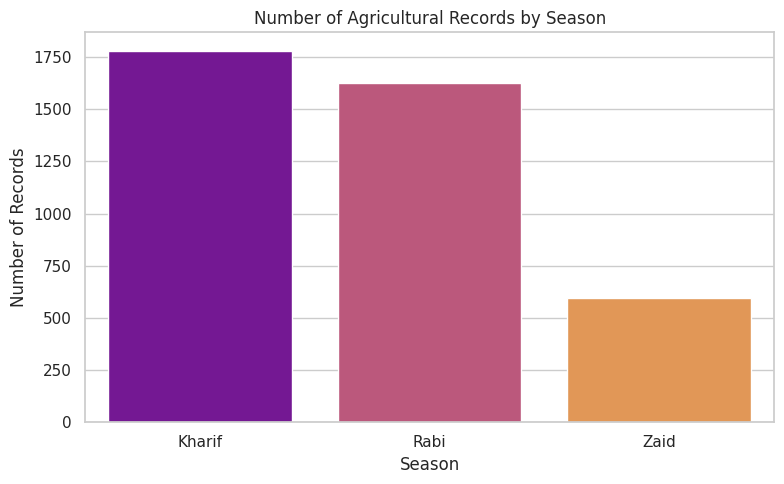

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season",
    palette="plasma",
    order= df["Season"].value_counts().index
)

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()ey di

###Interpretation-
This chart shows how many agricultural records belong to each season. We should check whether the seasons have reasonably comparable numbers of observations before comparing averages.

In [ ]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Values": missing_values.values,
    "Missing_Percentage": (missing_values.values / len(df)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing_Values"] > 0
].sort_values(
    by="Missing_Values",
    ascending=False
)

missing_summary

,Column,Missing_Values,Missing_Percentage
6,Rainfall_mm,48,1.20
11,Soil_Moisture_pct,40,1.00
19,Yield_Tonnes_Ha,32,0.80


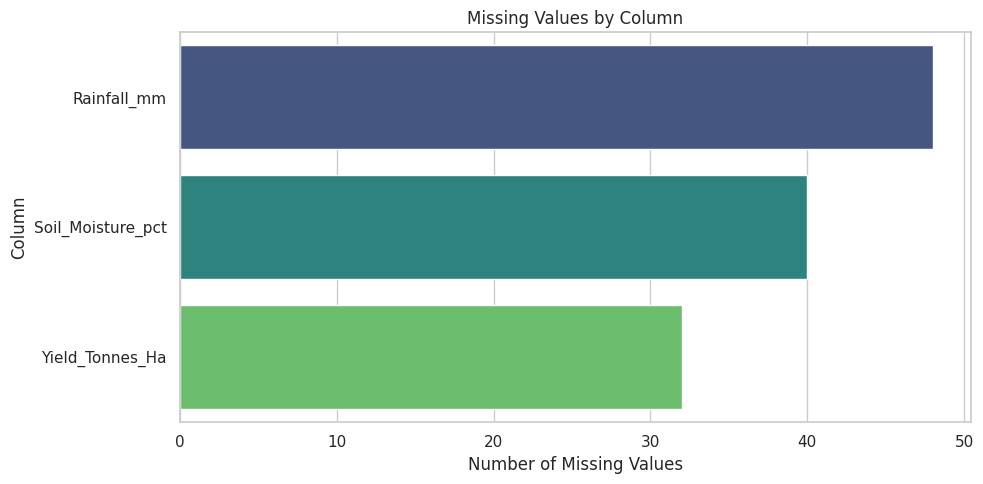

In [ ]:
plt.figure(figsize=(10, 5))

missing_plot = missing_summary[
    missing_summary["Missing_Values"] > 0
]

sns.barplot(
    data=missing_plot,
    x="Missing_Values",
    y="Column",
    palette="viridis"
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [ ]:
# Display data types before conversion
print(df.dtypes)

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [ ]:
# Columns that should contain numerical values
numeric_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

# Convert numeric columns safely
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Numeric columns converted successfully.")

Numeric columns converted successfully.


In [ ]:
# Check missing values before imputation
missing_before = df[numeric_columns].isnull().sum()

print("Missing values before imputation:")
print(missing_before[missing_before > 0])

Missing values before imputation:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [ ]:
# Fill missing numerical values with their respective median
for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)

print("Missing numerical values handled using median imputation.")

Missing numerical values handled using median imputation.


In [ ]:
print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [ ]:
non_negative_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

for column in non_negative_columns:
    negative_count = (df[column] < 0).sum()
    if negative_count > 0:
        print(f"{column}: {negative_count} negative values")

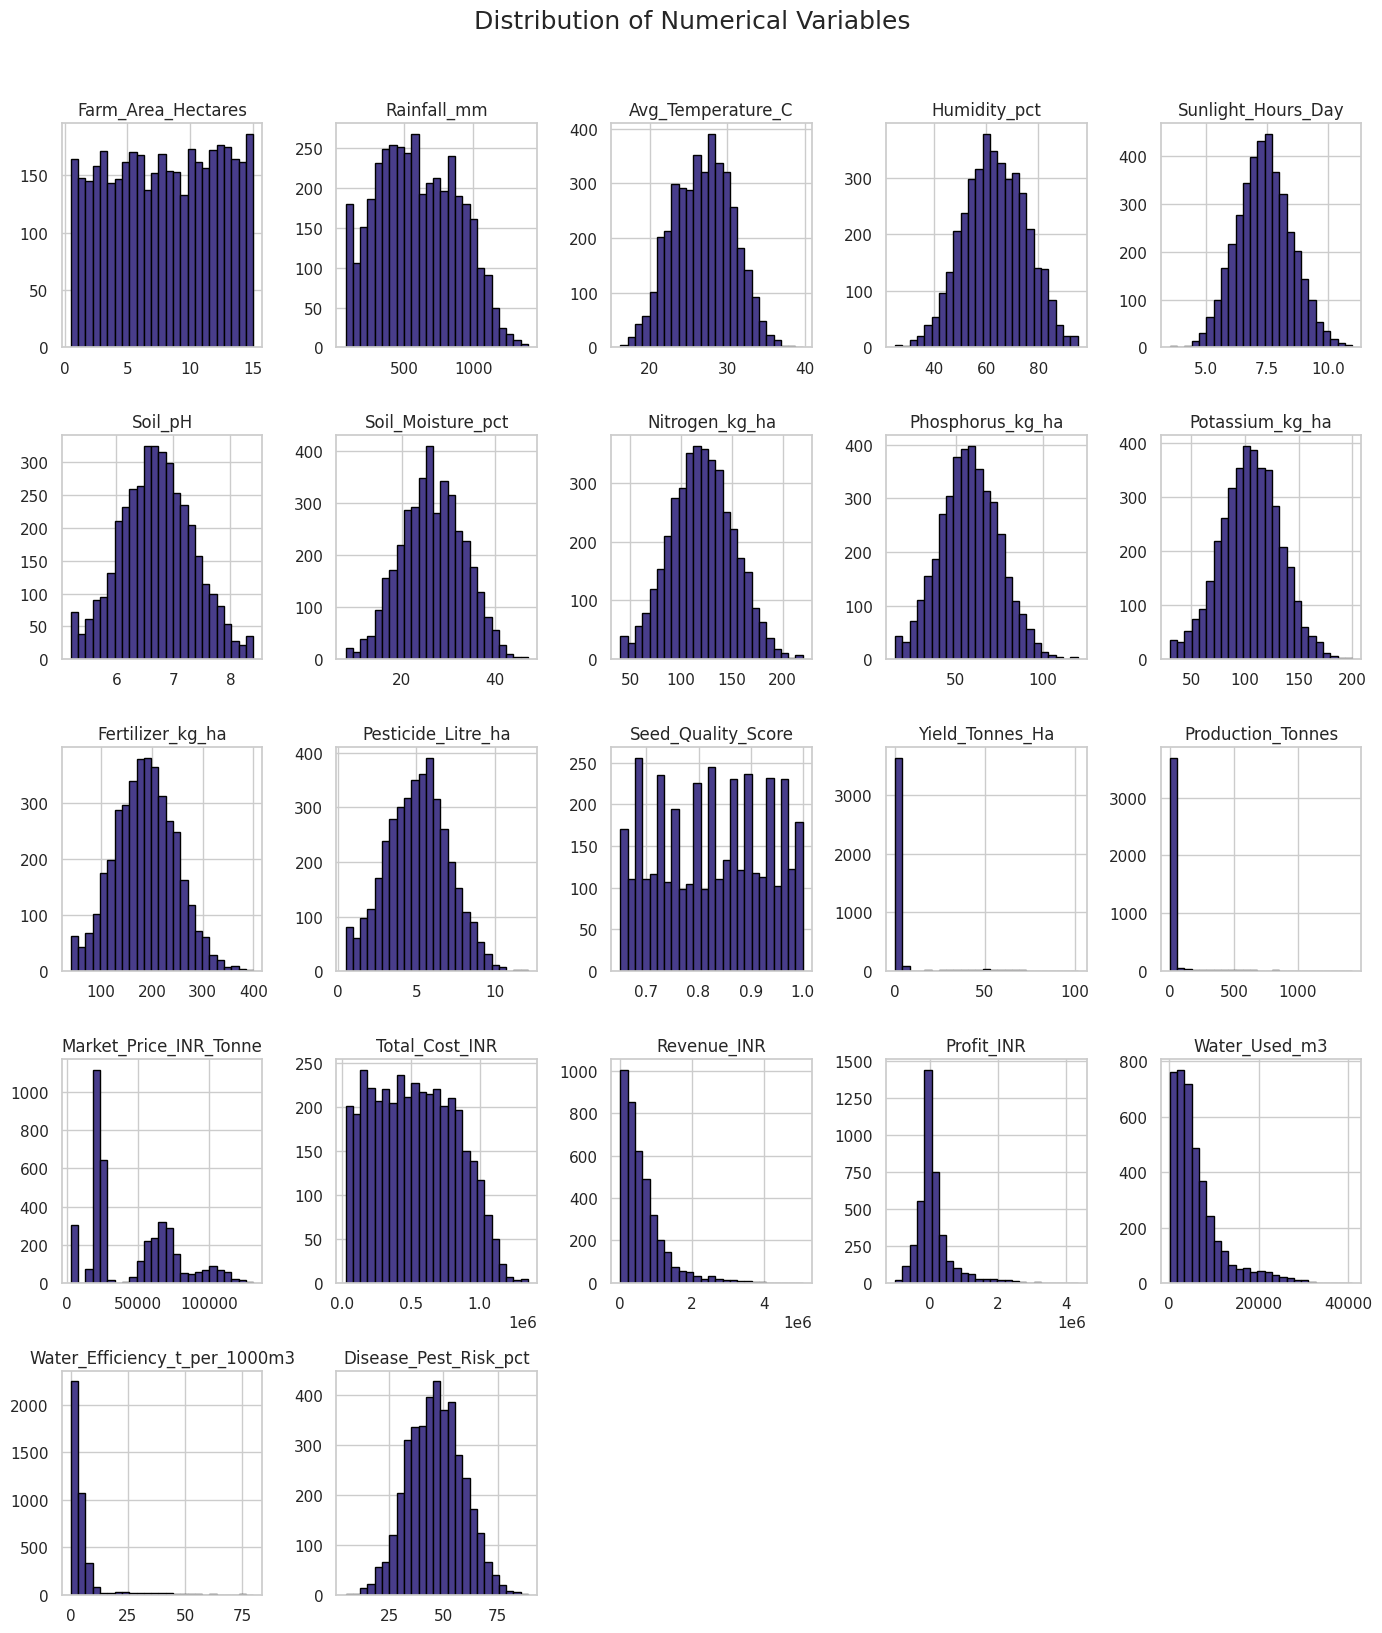

In [ ]:
df[numeric_columns].hist(
    figsize=(14, 16),
    bins=25,
    edgecolor="black",
    color='darkslateblue'
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

###Crop distribution

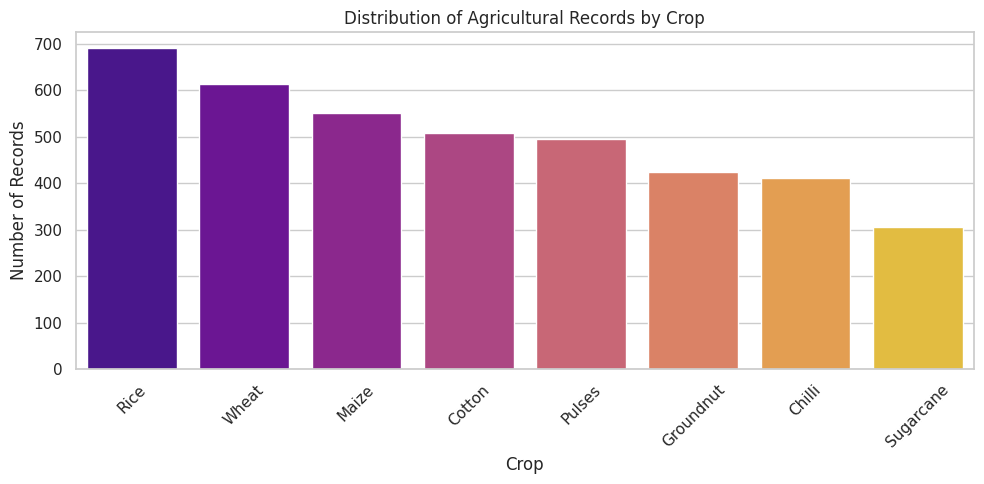

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index,
    palette="plasma"
)

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###statewise distribution

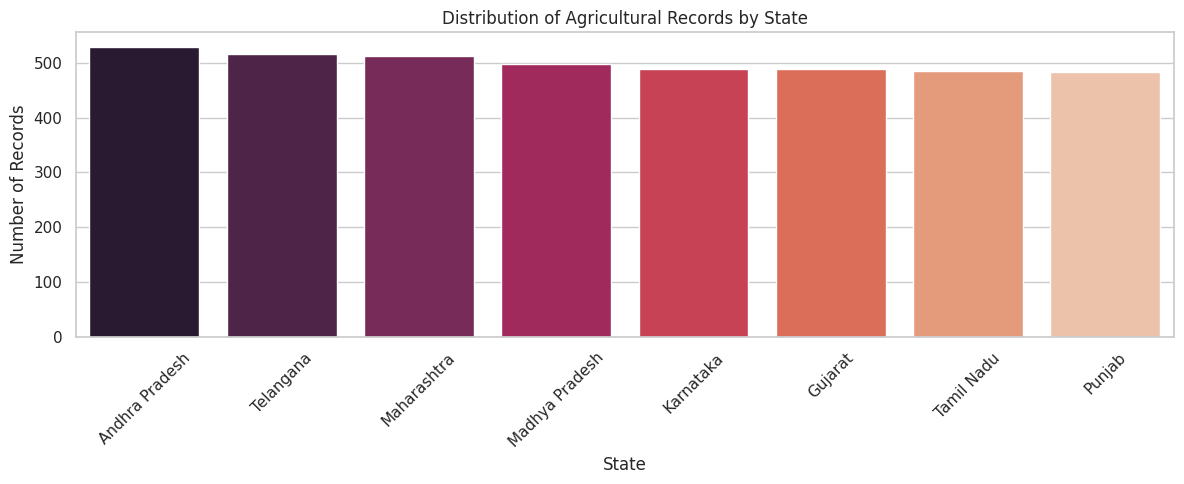

In [ ]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="State",
    order=df["State"].value_counts().index,
    palette="rocket"

)

plt.title("Distribution of Agricultural Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Irrigation method distribution

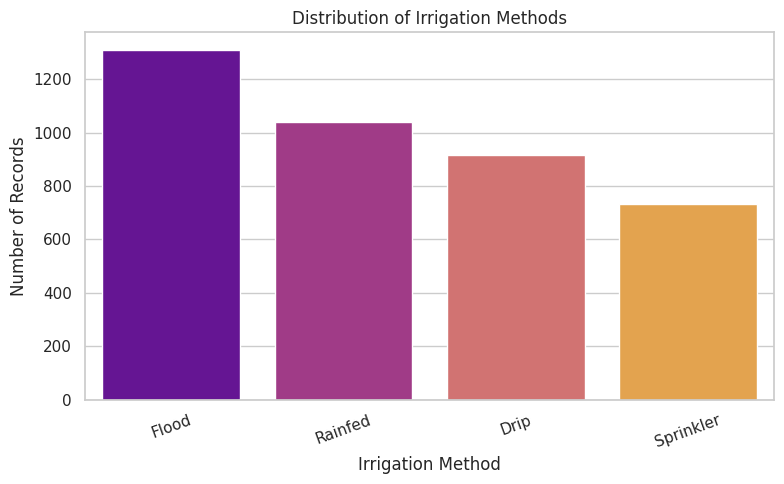

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Irrigation_Method",
    order=df["Irrigation_Method"].value_counts().index,
    palette="plasma"
)

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

###Seasonal Agricultural Performance

In [ ]:
seasonal_summary = df.groupby("Season").agg(
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Production_Tonnes=("Production_Tonnes", "mean"),
    Average_Revenue_INR=("Revenue_INR", "mean"),
    Average_Cost_INR=("Total_Cost_INR", "mean"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

seasonal_summary

,Average_Yield_Tonnes_Ha,Average_Production_Tonnes,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Water_Used_m3,Average_Water_Efficiency
Season,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41


In [ ]:
seasonal_counts = df["Season"].value_counts().rename("Number_of_Records")

seasonal_summary = seasonal_counts.to_frame().join(seasonal_summary)

seasonal_summary

,Number_of_Records,Average_Yield_Tonnes_Ha,Average_Production_Tonnes,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Water_Used_m3,Average_Water_Efficiency
Season,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41


###Result 1:

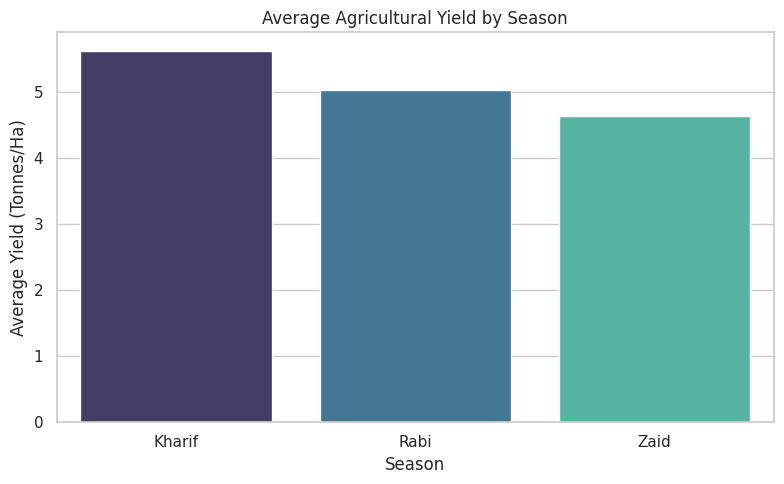

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None,
    palette="mako"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [ ]:
yield_by_season = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(
    ascending=False
)

print("Average Yield by Season:")
print(yield_by_season)

print("\nHighest average yield season:", yield_by_season.idxmax())
print("Lowest average yield season:", yield_by_season.idxmin())

Average Yield by Season:
Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64

Highest average yield season: Kharif
Lowest average yield season: Zaid


The analysis compares average yield across the three agricultural seasons. The season with the highest average yield is identified from the dataset, while the lowest-performing season is also examined.

In [ ]:
performance_columns = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR"
]

performance_by_season = df.groupby("Season")[performance_columns].mean().round(2)

performance_by_season

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65
Rabi,5.04,41.49,601526.05,513836.58,87689.47
Zaid,4.64,38.89,519171.90,543976.73,-24804.82


###Seasonal performance

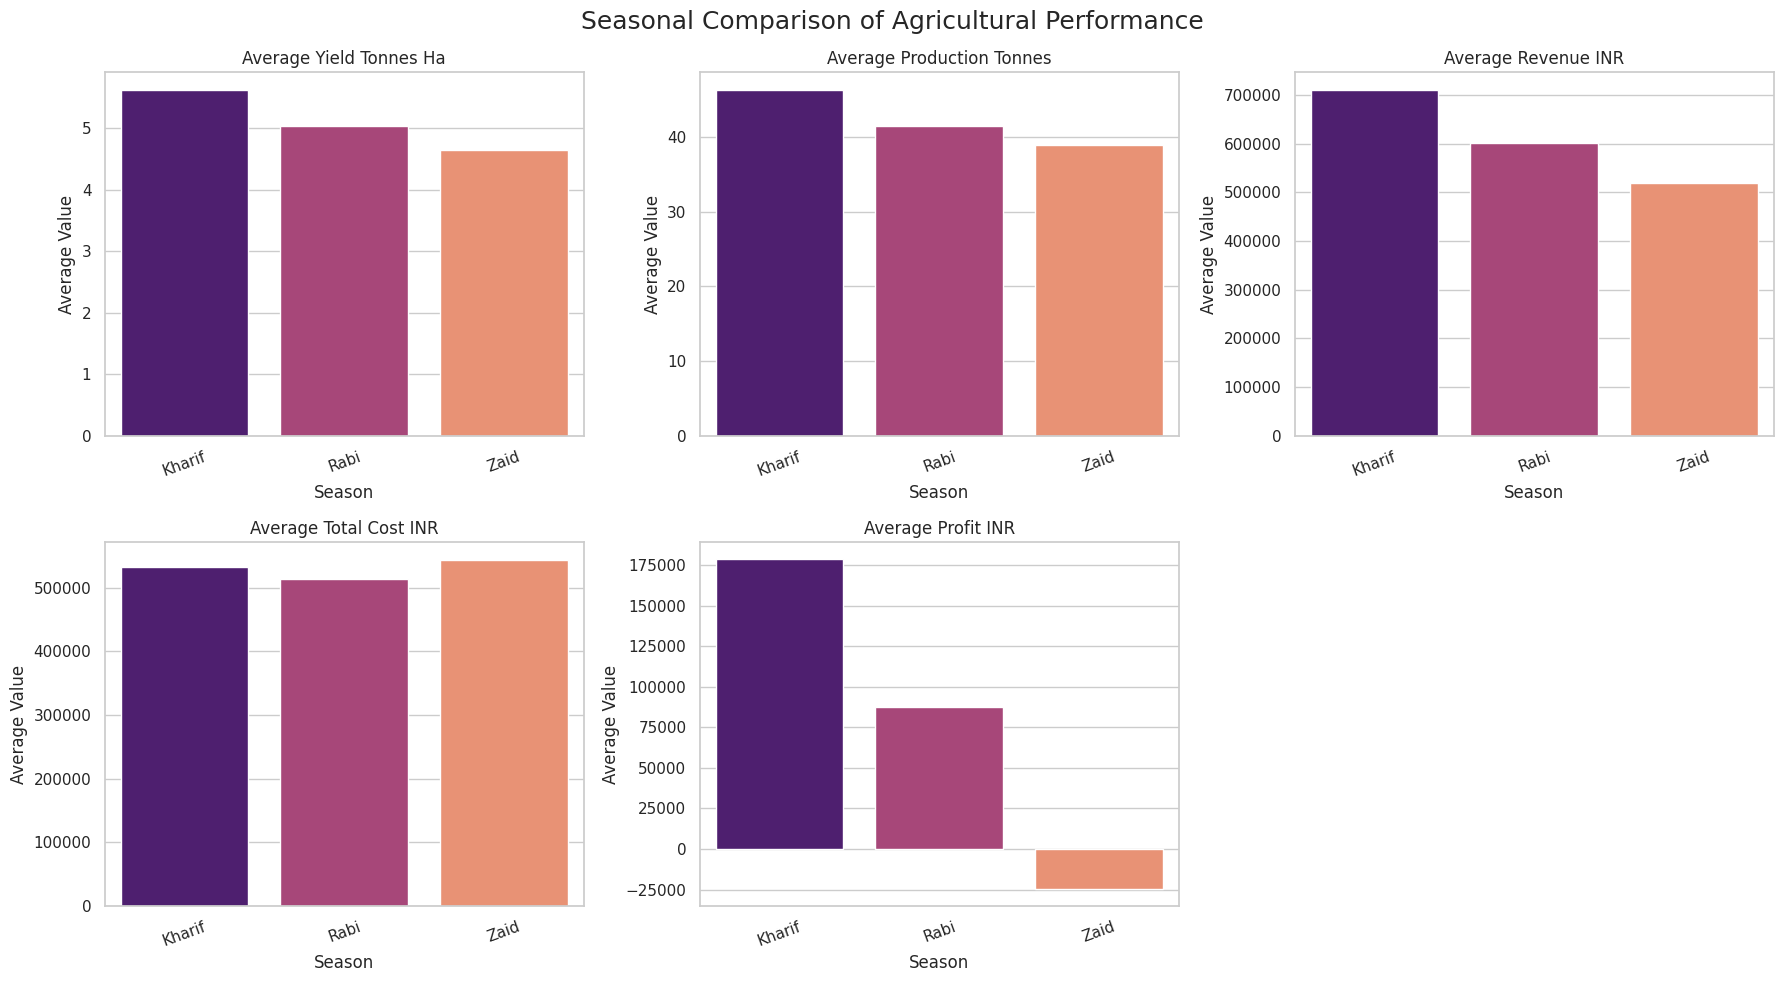

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, column in zip(axes.flatten(), performance_columns):
    sns.barplot(
        data=df,
        x="Season",
        y=column,
        estimator="mean",
        errorbar=None,
        ax=ax,
        palette="magma"
    )
    ax.set_title(f"Average {column.replace('_', ' ')}")
    ax.set_xlabel("Season")
    ax.set_ylabel("Average Value")
    ax.tick_params(axis="x", rotation=20)

# Hide unused subplot
axes.flatten()[-1].axis("off")

plt.suptitle(
    "Seasonal Comparison of Agricultural Performance",
    fontsize=18
)

plt.tight_layout()
plt.show()

###Seasonal profit comparison

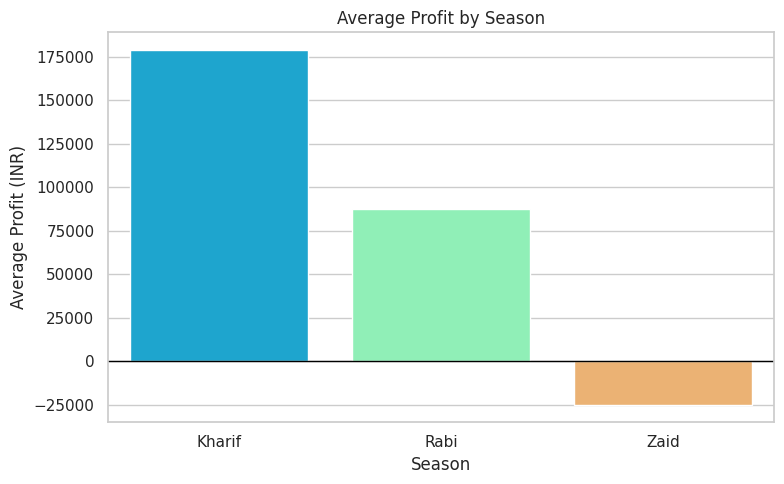

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None,
    palette="rainbow"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

In [ ]:
profit_by_season = df.groupby("Season")["Profit_INR"].mean().sort_values(
    ascending=False
)

print(profit_by_season)

Season
Kharif   178914.65
Rabi      87689.47
Zaid     -24804.82
Name: Profit_INR, dtype: float64


###Environmental Conditions Across Seasons

In [ ]:
environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

environmental_summary = df.groupby("Season")[environmental_columns].mean().round(2)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,6.73,31.15
Rabi,437.62,23.49,57.89,7.59,6.67,24.07
Zaid,304.65,31.04,52.01,8.18,6.69,19.28


###Result 2: Environmental conditions heatmap

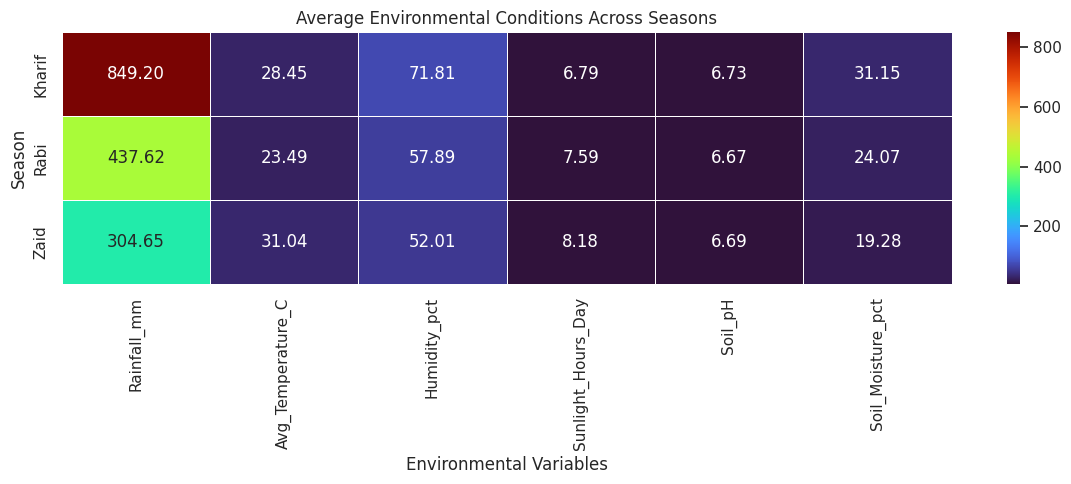

In [ ]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    environmental_summary,
    annot=True,
    fmt=".2f",
    cmap="turbo",
    linewidths=0.5
)

plt.title("Average Environmental Conditions Across Seasons")
plt.xlabel("Environmental Variables")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

###Box plots for environmental variation

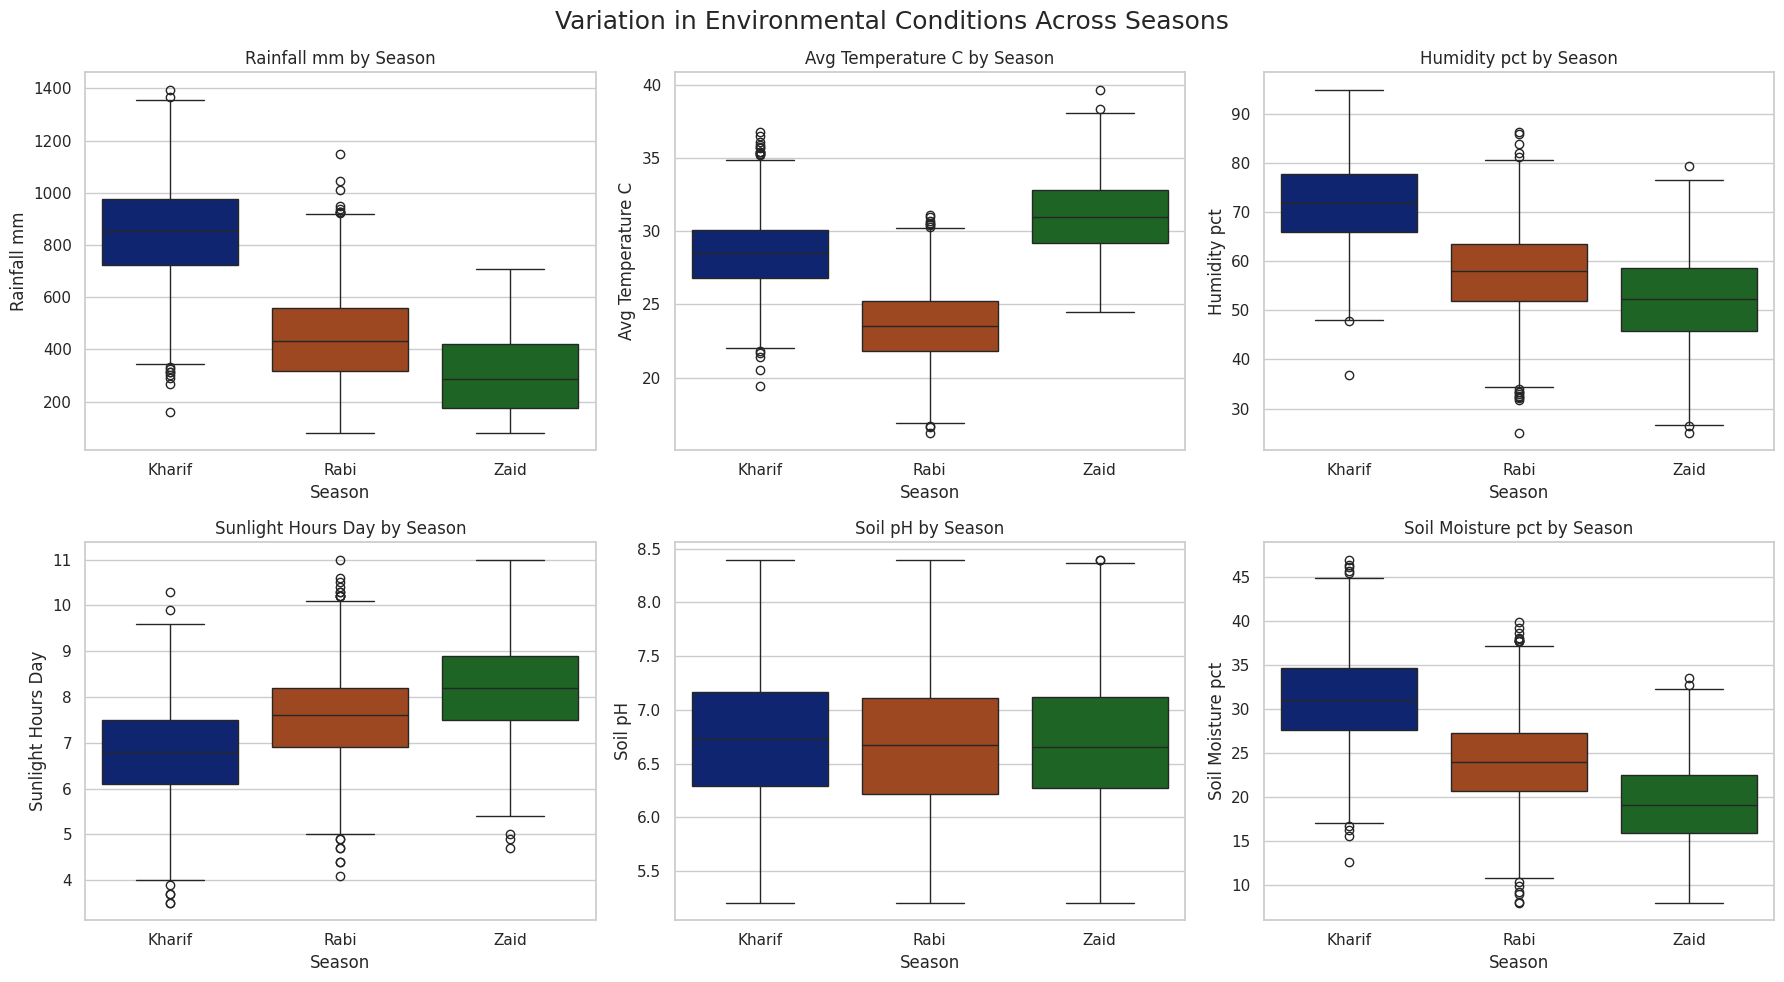

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, column in zip(axes.flatten(), environmental_columns):
    sns.boxplot(
        data=df,
        x="Season",
        y=column,
        ax=ax,
        palette="dark"
    )
    ax.set_title(f"{column.replace('_', ' ')} by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel(column.replace("_", " "))

plt.suptitle(
    "Variation in Environmental Conditions Across Seasons",
    fontsize=18
)

plt.tight_layout()
plt.show()

###Resource Usage and Irrigation Analysis

In [ ]:
resource_columns = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3"
]

resource_summary = df.groupby("Season")[resource_columns].mean().round(2)

resource_summary

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


###Result 3: Resource usage comparison

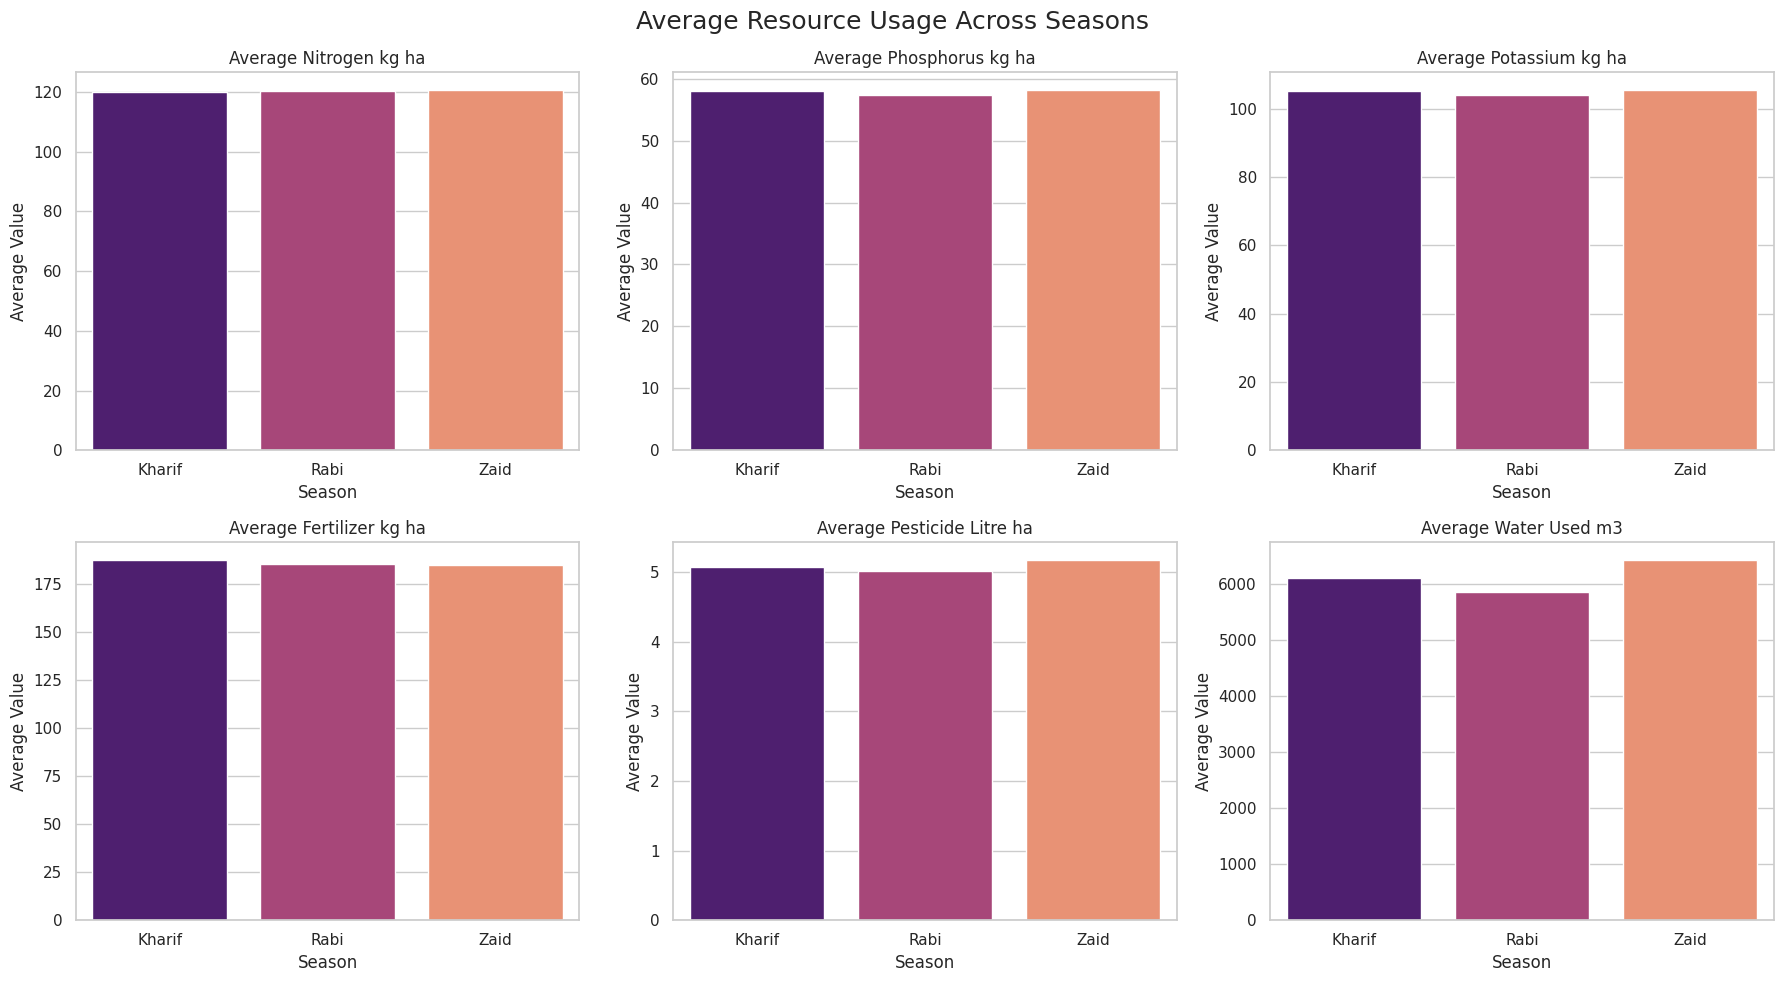

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, column in zip(axes.flatten(), resource_columns):
    sns.barplot(
        data=df,
        x="Season",
        y=column,
        estimator="mean",
        errorbar=None,
        ax=ax,
        palette="magma"
    )
    ax.set_title(f"Average {column.replace('_', ' ')}")
    ax.set_xlabel("Season")
    ax.set_ylabel("Average Value")

plt.suptitle(
    "Average Resource Usage Across Seasons",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [ ]:
irrigation_yield = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Number_of_Records=("Farm_ID", "count")
).round(2)

irrigation_yield

,Average_Yield,Average_Production,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Number_of_Records
Irrigation_Method,,,,,,
Drip,6.58,57.99,219626.00,5918.75,6.27,915
Flood,4.86,38.73,73354.02,8026.47,3.44,1310
Rainfed,4.60,36.61,79050.37,3549.55,7.56,1041
Sprinkler,5.16,42.34,91121.08,6208.26,4.67,734


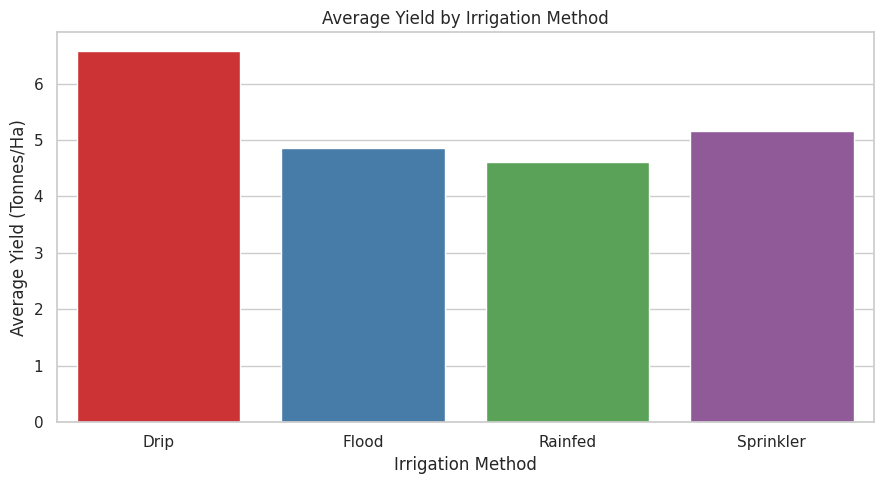

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None,
    palette="Set1"
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

###Irrigation method vs water efficiency

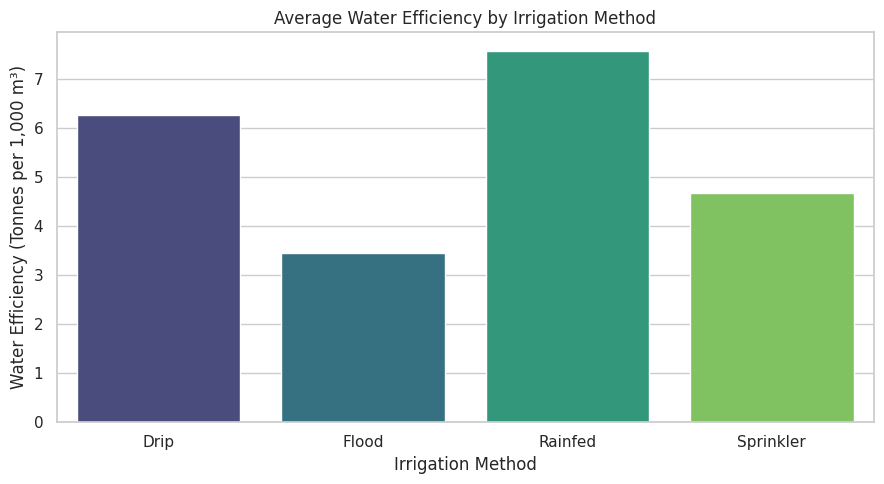

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None,
    palette="viridis"
)

plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.tight_layout()
plt.show()

###Interpretation

Yield and water efficiency are different measures. We should not automatically call the method with the highest yield the most water-efficient method. We will report them separately.

###Relationship Analysis

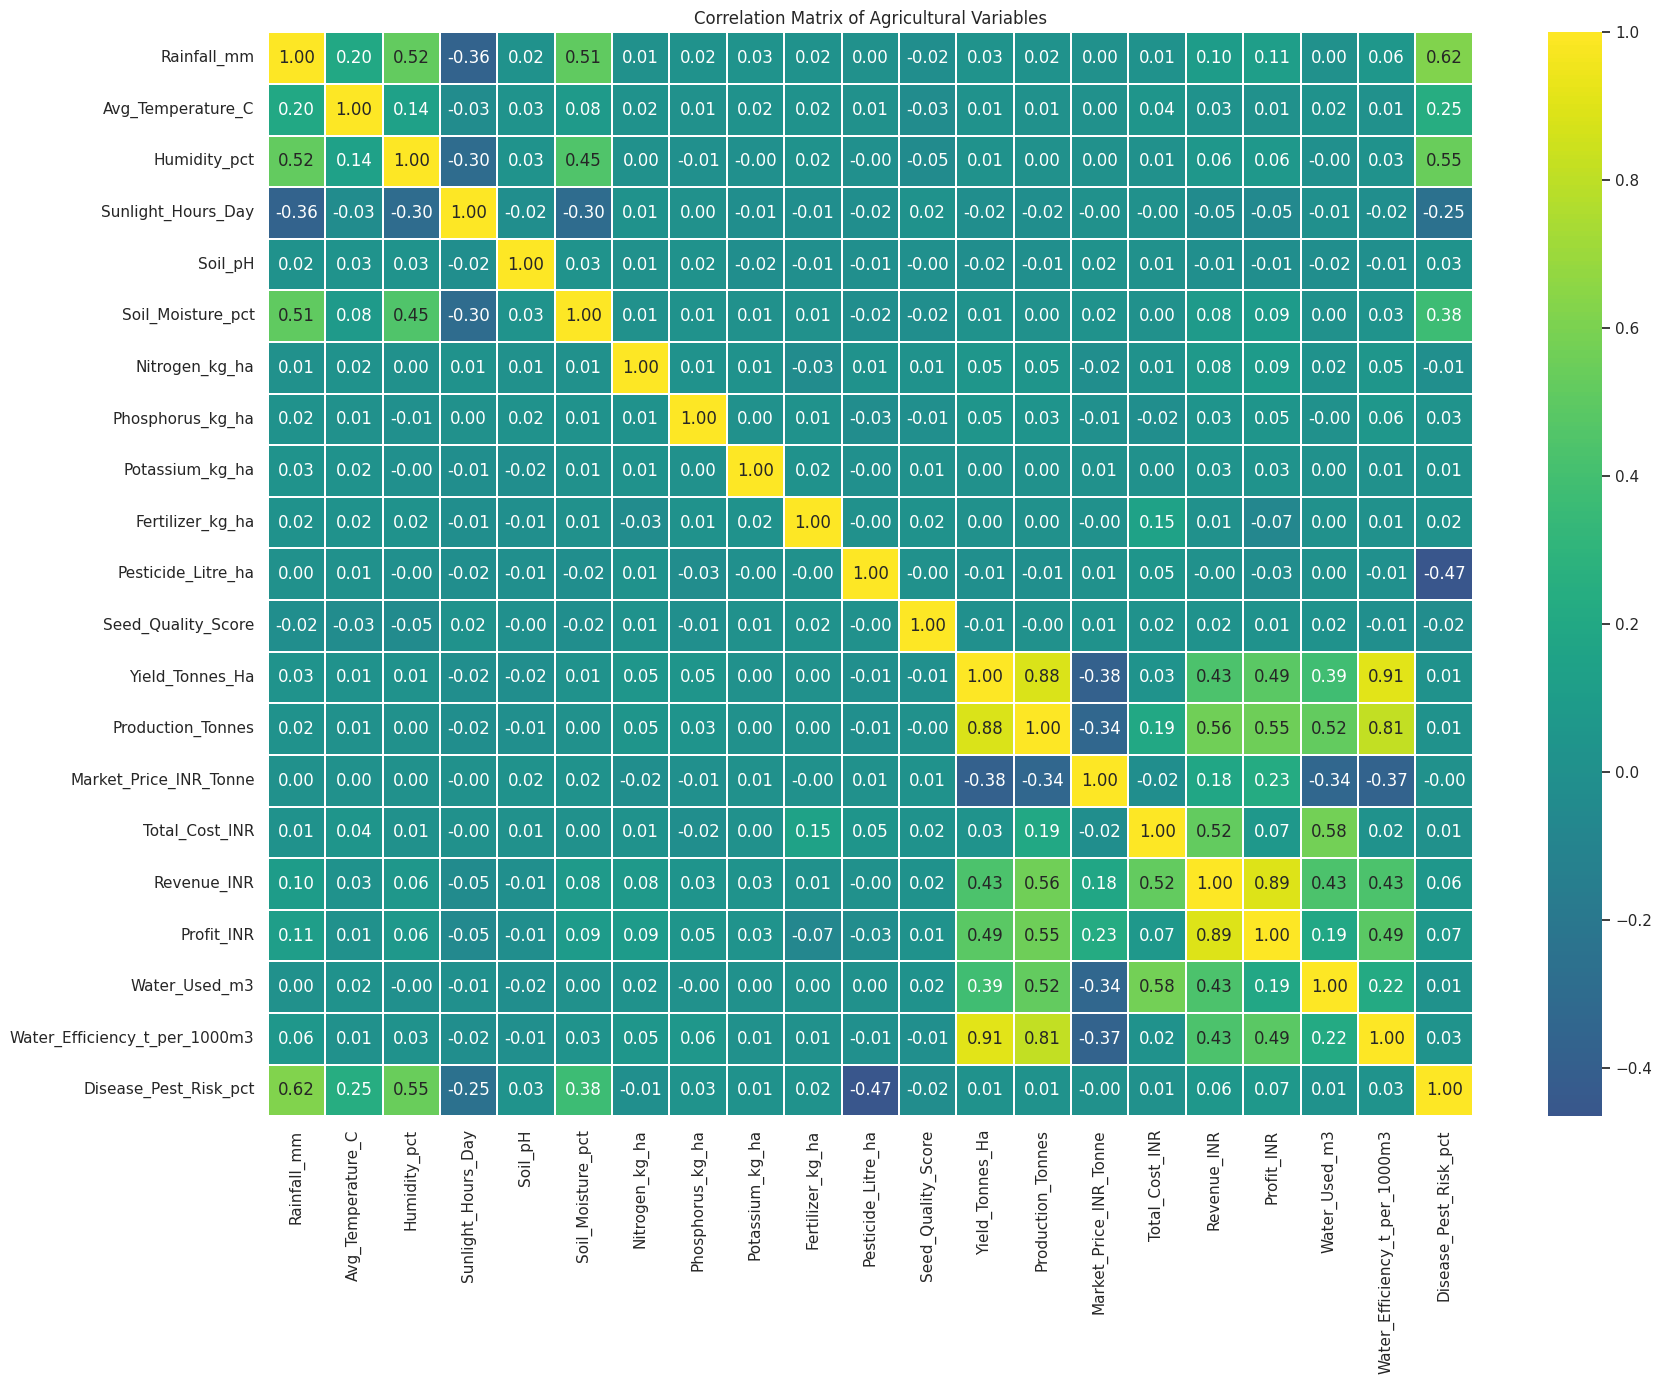

In [ ]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

*   A value close to +1 indicates a strong positive linear relationship.

*   A value close to −1 indicates a strong negative linear relationship.

*   A value close to 0 indicates a weak linear relationship.


In [ ]:
yield_correlations = correlation_matrix["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

print("Correlation of variables with Yield:")
print(yield_correlations)

Correlation of variables with Yield:
Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64


###Result 4: Selected scatter plots

##Rainfall vs Yield

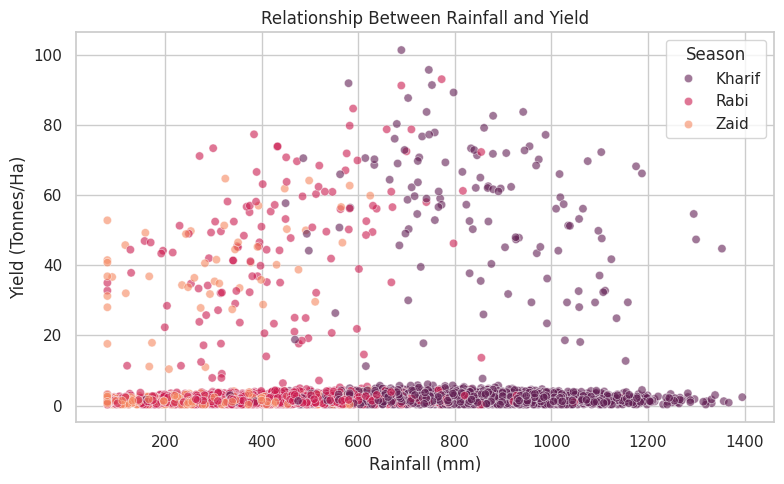

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6,
    palette="rocket"
)

plt.title("Relationship Between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

##Fertilizer vs yield

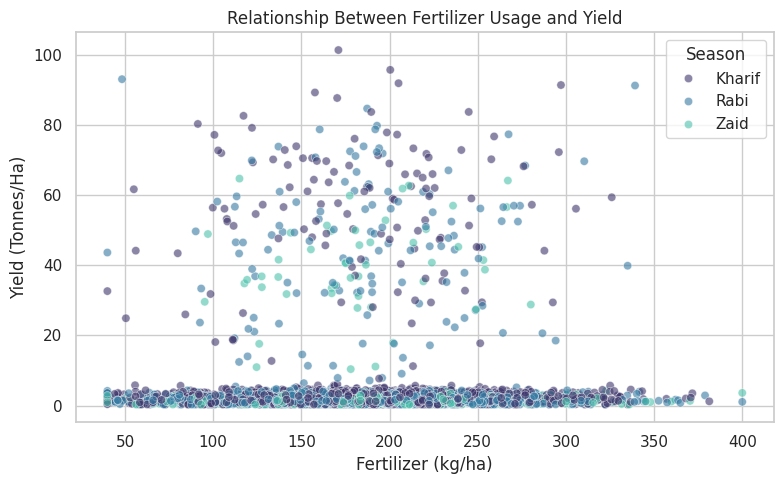

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6,
    palette="mako"
)

plt.title("Relationship Between Fertilizer Usage and Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

##Soil moisture vs yield

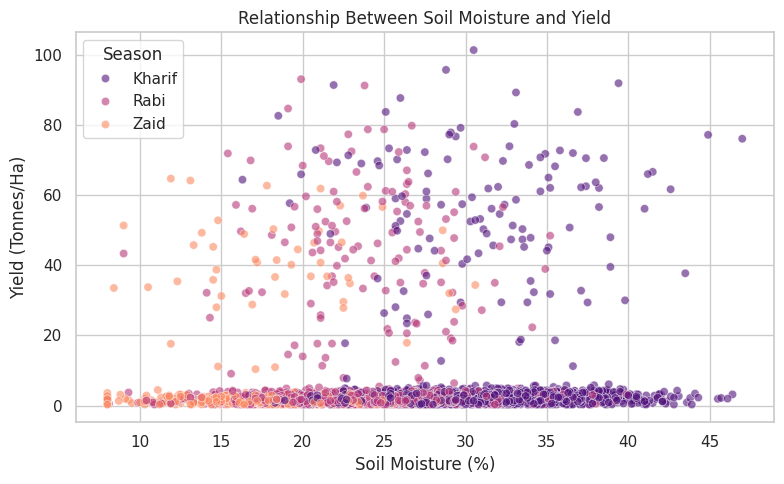

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6,
    palette="magma"
)

plt.title("Relationship Between Soil Moisture and Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

##Yield vs profit

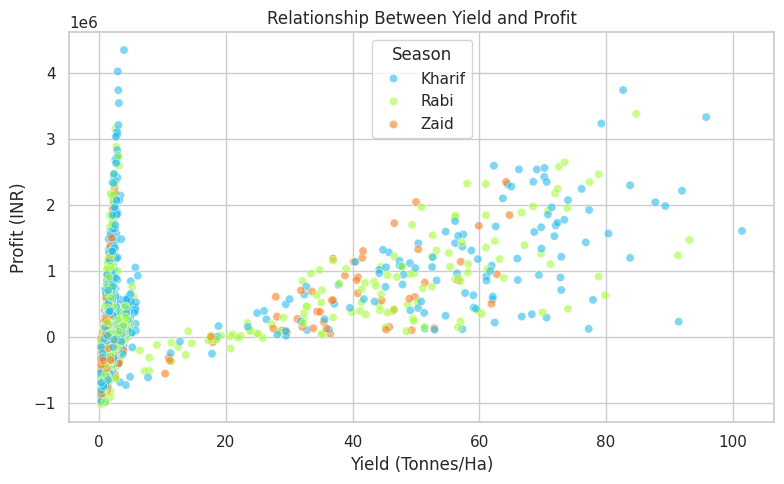

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    alpha=0.6,
    palette="turbo"
)

plt.title("Relationship Between Yield and Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

###Average yield by crop and season

In [ ]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


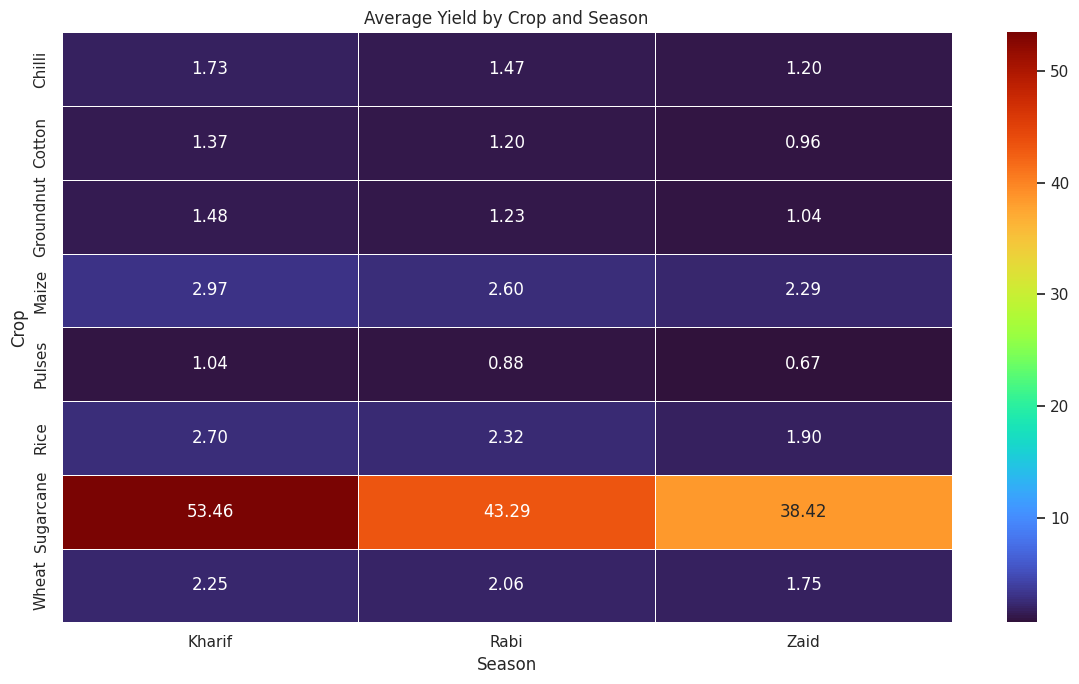

In [ ]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="turbo",
    linewidths=0.5
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

##State-wise seasonal performance

In [ ]:
state_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
).round(2)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


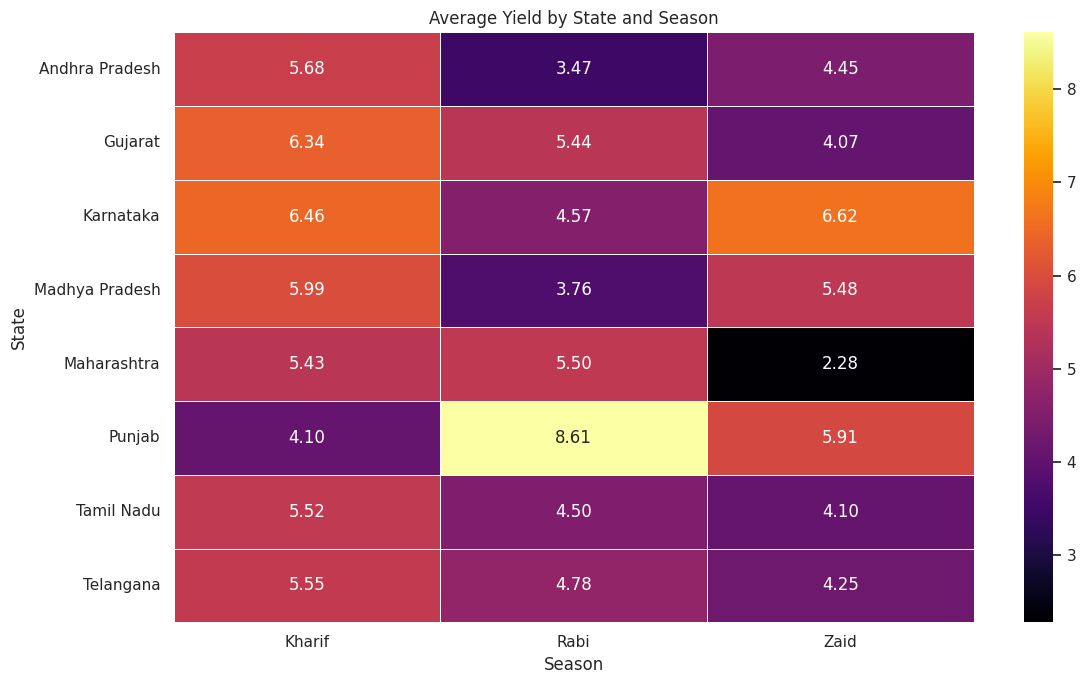

In [ ]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f",
    cmap="inferno",
    linewidths=0.5
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# AUTOMATIC KEY FINDINGS
# ============================================

print("=" * 60)
print("KEY FINDINGS FROM SEASONAL AGRICULTURE ANALYSIS")
print("=" * 60)

# 1. Yield
yield_by_season = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print("\n1. SEASONAL YIELD")
print(yield_by_season.round(2))
print(
    f"Highest average yield: {yield_by_season.idxmax()} "
    f"({yield_by_season.max():.2f} tonnes/ha)"
)
print(
    f"Lowest average yield: {yield_by_season.idxmin()} "
    f"({yield_by_season.min():.2f} tonnes/ha)"
)

# 2. Profit
profit_by_season = df.groupby("Season")["Profit_INR"].mean()

print("\n2. SEASONAL PROFIT")
print(profit_by_season.round(2))
print(
    f"Highest average profit: {profit_by_season.idxmax()} "
    f"(INR {profit_by_season.max():,.2f})"
)
print(
    f"Lowest average profit: {profit_by_season.idxmin()} "
    f"(INR {profit_by_season.min():,.2f})"
)

# 3. Rainfall
rainfall_by_season = df.groupby("Season")["Rainfall_mm"].mean()

print("\n3. SEASONAL RAINFALL")
print(rainfall_by_season.round(2))
print(
    f"Highest average rainfall: {rainfall_by_season.idxmax()} "
    f"({rainfall_by_season.max():.2f} mm)"
)

# 4. Irrigation yield
yield_by_irrigation = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean()

print("\n4. IRRIGATION METHOD AND YIELD")
print(yield_by_irrigation.round(2))
print(
    f"Highest average yield by irrigation method: "
    f"{yield_by_irrigation.idxmax()} "
    f"({yield_by_irrigation.max():.2f} tonnes/ha)"
)

# 5. Water efficiency
efficiency_by_irrigation = df.groupby("Irrigation_Method")[
    "Water_Efficiency_t_per_1000m3"
].mean()

print("\n5. IRRIGATION METHOD AND WATER EFFICIENCY")
print(efficiency_by_irrigation.round(2))
print(
    f"Highest average water efficiency: "
    f"{efficiency_by_irrigation.idxmax()} "
    f"({efficiency_by_irrigation.max():.2f})"
)

# 6. Strongest correlations with yield
print("\n6. VARIABLES CORRELATED WITH YIELD")

yield_corr = df[correlation_columns].corr()["Yield_Tonnes_Ha"].drop(
    "Yield_Tonnes_Ha"
).sort_values(ascending=False)

print(yield_corr.head(5).round(3))

print("\n" + "=" * 60)

KEY FINDINGS FROM SEASONAL AGRICULTURE ANALYSIS

1. SEASONAL YIELD
Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64
Highest average yield: Kharif (5.63 tonnes/ha)
Lowest average yield: Zaid (4.64 tonnes/ha)

2. SEASONAL PROFIT
Season
Kharif   178914.65
Rabi      87689.47
Zaid     -24804.82
Name: Profit_INR, dtype: float64
Highest average profit: Kharif (INR 178,914.65)
Lowest average profit: Zaid (INR -24,804.82)

3. SEASONAL RAINFALL
Season
Kharif   849.20
Rabi     437.62
Zaid     304.65
Name: Rainfall_mm, dtype: float64
Highest average rainfall: Kharif (849.20 mm)

4. IRRIGATION METHOD AND YIELD
Irrigation_Method
Drip        6.58
Flood       4.86
Rainfed     4.60
Sprinkler   5.16
Name: Yield_Tonnes_Ha, dtype: float64
Highest average yield by irrigation method: Drip (6.58 tonnes/ha)

5. IRRIGATION METHOD AND WATER EFFICIENCY
Irrigation_Method
Drip        6.27
Flood       3.44
Rainfed     7.56
Sprinkler   4.67
Name: Water_Efficiency_t_per_1000m3, d